# Compare MIRI: Direct pRT vs Pipeline

Wavelength range: 4.9 – 19 μm

In [1]:
import os
os.environ['pRT_input_data_path'] = '/media/mvasist/Elements/PhDprojects/scratch/input_data_v2.4.9/input_data'

import sys
sys.path.insert(0, '/home/mvasist/Documents/SBI4atmret')
sys.path.insert(0, '/home/mvasist/Documents/WISEJ1738/sbi_ear')

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

from petitRADTRANS import nat_cst as nc, Radtrans
import petitRADTRANS as prt
import petitRADTRANS.retrieval.parameter as prm
from petitRADTRANS.retrieval.util import calc_MMW

from sbi4atmret.config.configs import BaseConfig
from sbi4atmret.datasets.theta_mapper.thetamapperbase import BaseThetaMapper

sys.path.insert(0, '/home/mvasist/Documents/WISEJ1738/sbi_ear')
from code2explore.observations import load_observations

obs_wlen_miri, obs_miri, sigmaM, \
    obs_wlen_gemini, obs_gemini, sigmaG, \
    obs_wlen_hst, obs_hst, sigmaH, \
    wlength_gm, wlength_hm, \
    x_star_g, x_star_h = load_observations()

print(f"MIRI: {len(obs_wlen_miri)} points")
print(f"HST: {len(obs_wlen_hst)} points")
print(f"Gemini: {len(obs_wlen_gemini)} points")


MIRI: 1298 points
HST: 129 points
Gemini: 305 points


## 1. Load config + build pipeline simulator

In [2]:
config_path = '/home/mvasist/Documents/SBI4atmret/experiments/config_MiriGeminiHST_cloudfree.yaml'
with open(config_path) as f:
    config = BaseConfig(**yaml.safe_load(f))

simulators = config.build_simulators()
prior = config.build_prior()

sim_name = 'cloudfree_miri'
simulator = simulators[sim_name]
print(f"Pipeline simulator: {sim_name}")
print(f"  wavelength range: [{simulator.a}, {simulator.b}] μm")
print(f"  params: {simulator.names}")
print(f"  scale: {simulator.scale}")

Pipeline simulator: cloudfree_miri
  wavelength range: [4.9, 19] μm
  params: ['R_pl', 'mass', 'T_bottom', 'temp_node_1', 'temp_node_2', 'temp_node_3', 'temp_node_4', 'temp_node_5', 'temp_node_6', 'temp_node_7', 'temp_node_8', 'temp_node_9', 'H2O_mol_scale', 'CO2_mol_scale', 'CO_mol_scale', 'CH4_mol_scale', 'NH3_mol_scale', 'PH3_mol_scale', 'H2S_mol_scale', '15NH3_mol_scale', 'HCN_mol_scale', 'TiO_mol_scale', 'VO_mol_scale', 'bfactor_noise_miri']
  scale: 100000.0


## 2. Build theta mapper + sample

In [3]:
class _MinimalDomain:
    def __init__(self, simulator_dict):
        self.simulator_dict = simulator_dict

theta_mapper = BaseThetaMapper(
    domain=_MinimalDomain(simulators),
    posterior_param_names=config.get_parameter_names(),
)

# Sample merged theta and split
theta_merged = prior.sample((1,))
theta_dict = theta_mapper.split_theta(theta_merged)

theta_miri = theta_dict[sim_name][0].numpy()
print(f"MIRI theta ({len(theta_miri)} params): {theta_miri}")

MIRI theta (24 params): [ 2.7111032e+00  4.1336203e+00  3.9596172e+03  8.9992344e-01
  2.4155155e-01  7.8785068e-01  3.7465420e-01  6.6304547e-01
  6.3913023e-01  4.6435559e-01  4.1300964e-01  8.5504627e-01
 -7.6199064e+00 -4.5952992e+00 -6.6595597e+00 -9.7627697e+00
 -4.2109842e+00 -4.0928407e+00 -8.4028053e+00 -8.9198408e+00
 -5.0960631e+00 -8.7471876e+00 -9.0014248e+00 -1.3775488e+01]


## 3. Run Pipeline Simulator

In [4]:
output_pipeline = simulator(theta_miri)

if output_pipeline.spectrum is not None:
    print(f"Pipeline SUCCESS")
    print(f"  spectrum: {output_pipeline.spectrum.shape}")
    print(f"  wavelength: [{output_pipeline.wavelength.min():.2f}, {output_pipeline.wavelength.max():.2f}] μm")
    print(f"  flux range: [{output_pipeline.spectrum.min():.2e}, {output_pipeline.spectrum.max():.2e}]")
else:
    print("Pipeline FAILED (None spectrum)")

Pipeline SUCCESS
  spectrum: (1355,)
  wavelength: [4.90, 19.00] μm
  flux range: [1.01e+00, 4.41e+02]


## 4. Run Direct pRT (old WISEJ1738 style)

In [5]:
# Import old simulator directly
from ees_MIRIinsts import Simulator as OldSimulator

old_sim = OldSimulator(a=4.9, b=19.0, noisy=False)
spectrum_old = old_sim(theta_miri)

wlen_old = old_sim.wavelength
print(f"Old simulator: {spectrum_old.shape} points")
print(f"  wavelength: [{wlen_old.min():.2f}, {wlen_old.max():.2f}] μm")
print(f"  flux range: [{spectrum_old.min():.2e}, {spectrum_old.max():.2e}]")

Old simulator: (1355,) points
  wavelength: [4.90, 19.00] μm
  flux range: [1.01e+00, 4.43e+02]


## 5. Compare

Same grid: (1355,) == (1355,)
Max |residual|: 8.39e+00
Mean |residual|: 2.76e+00


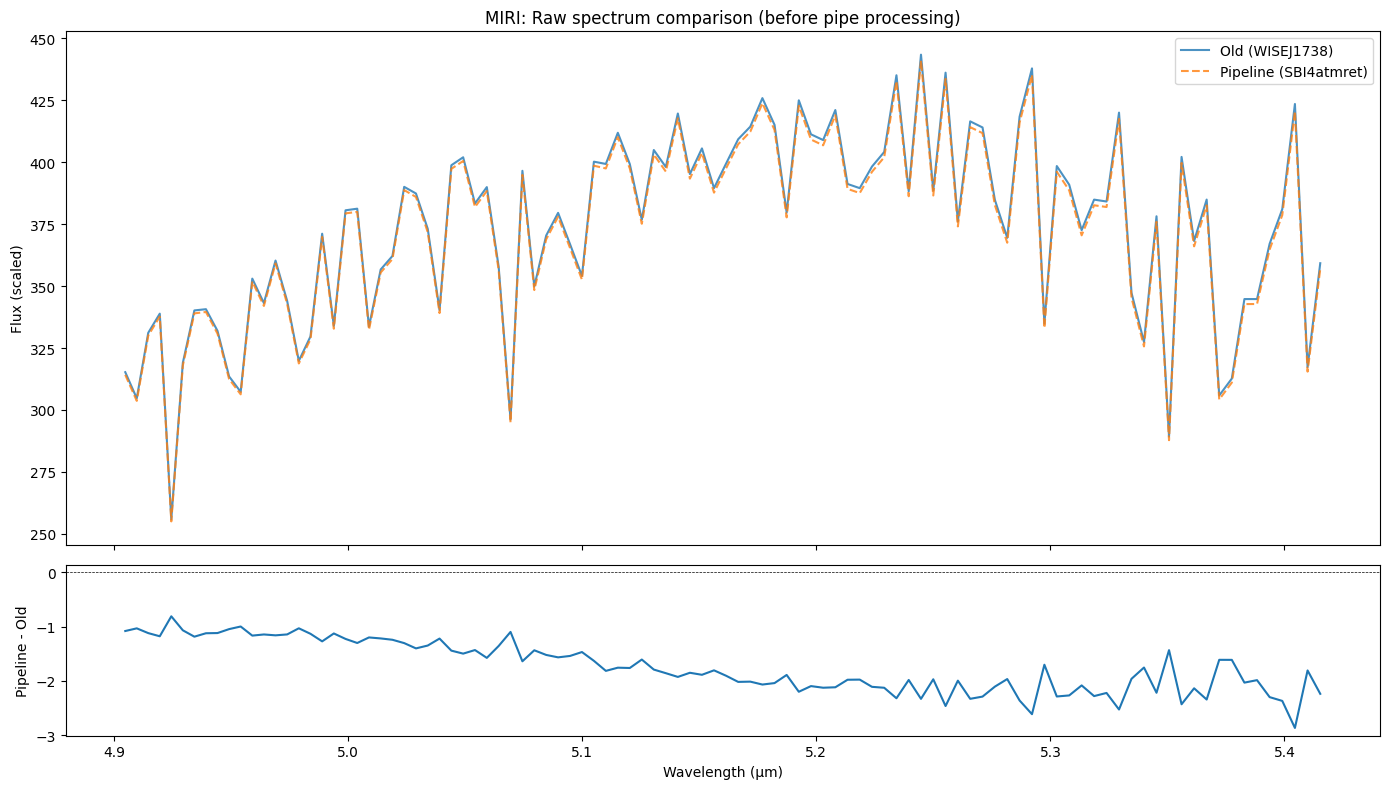

In [6]:

# Residual — direct comparison (same wavelength grid, apply pipe trimming)
if output_pipeline.spectrum is not None:
    # Old simulator produces the full spectrum on the same pRT wavelength grid
    # The pipe trims MIRI to indices 1:1299
    spectrum_old_scaled = spectrum_old 
    spectrum_old_trimmed = spectrum_old_scaled[1:1299]  # same as pipe.modify_spec for MIRI
    
    # Pipeline output should already be trimmed (from _compute_emission → process)
    # But pipeline returns the FULL raw spectrum (before pipe processing)
    # So compare raw-to-raw first:
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})
    
    # Full raw spectra (before pipe trimming)
    ax1.plot(wlen_old[:100], spectrum_old_scaled[:100], label='Old (WISEJ1738)', alpha=0.8)
    ax1.plot(output_pipeline.wavelength[:100], output_pipeline.spectrum[:100],
             label='Pipeline (SBI4atmret)', alpha=0.8, linestyle='--')
    ax1.set_ylabel('Flux (scaled)')
    ax1.legend()
    ax1.set_title('MIRI: Raw spectrum comparison (before pipe processing)')
    
    # Direct residual on same grid (no interpolation)
    # Both should have the same wavelength grid from pRT
    if output_pipeline.wavelength.shape == wlen_old.shape:
        residual = output_pipeline.spectrum - spectrum_old_scaled
        ax2.plot(output_pipeline.wavelength[:100], residual[:100])
        ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax2.set_ylabel('Pipeline - Old')
        ax2.set_xlabel('Wavelength (μm)')
        print(f"Same grid: {output_pipeline.wavelength.shape} == {wlen_old.shape}")
        print(f"Max |residual|: {np.max(np.abs(residual)):.2e}")
        print(f"Mean |residual|: {np.mean(np.abs(residual)):.2e}")
    else:
        print(f"DIFFERENT grid sizes: pipeline={output_pipeline.wavelength.shape}, old={wlen_old.shape}")
        print("  This means the emission models produce different grid sizes.")
        print(f"  Pipeline: [{output_pipeline.wavelength.min():.4f}, {output_pipeline.wavelength.max():.4f}]")
        print(f"  Old:      [{wlen_old.min():.4f}, {wlen_old.max():.4f}]")
    
    plt.tight_layout()
    plt.show()


Pipeline processed shapes:
  MIRI:   (1298,)
MIRI — Max |residual|: 1.52e-05


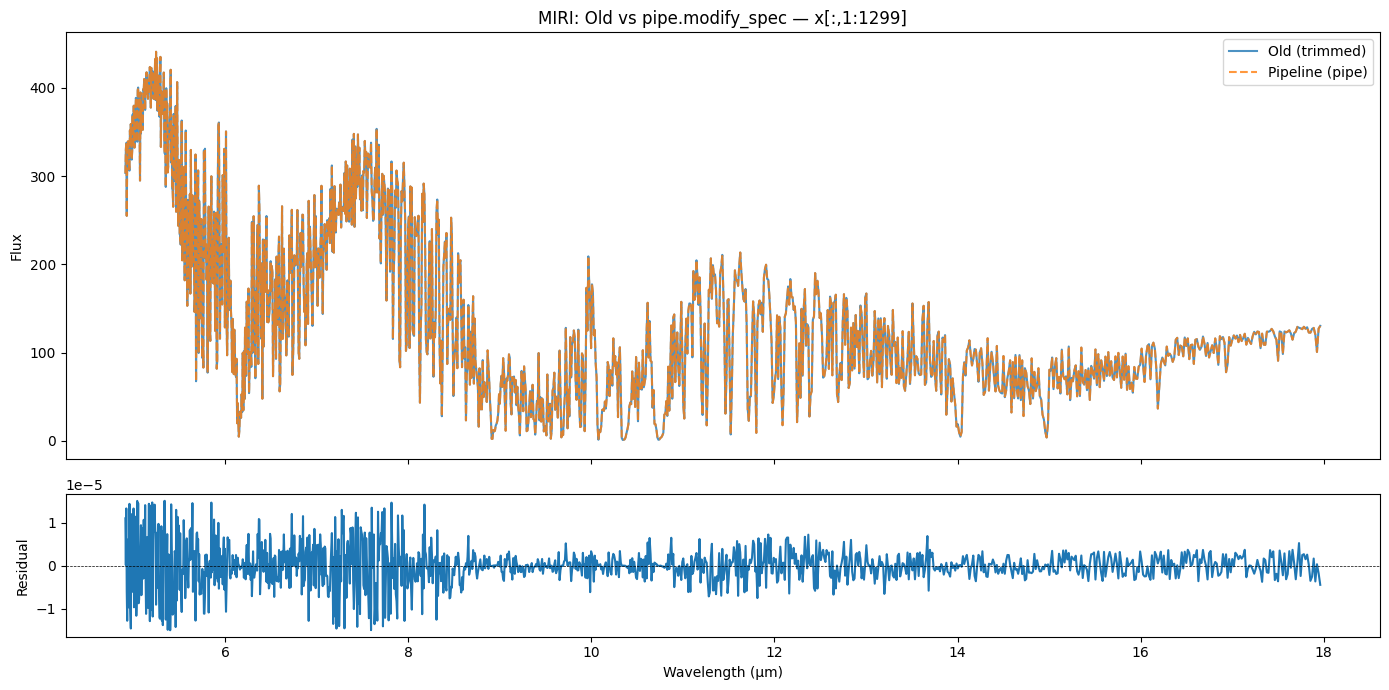

In [7]:
# ============================================================
# 6. Compare AFTER pipe processing — use pipe.modify_spec
# ============================================================

from petitRADTRANS.retrieval.rebin_give_width import rebin_give_width
from petitRADTRANS.retrieval.data import Data

# --- Pipeline: use the actual pipe class ---
# Build a batch_dict with all simulators' outputs (pipe expects all 3)
# We need outputs from all simulators for the same theta

# Run all simulators with the same merged theta
theta_dict_all = theta_mapper.split_theta(theta_merged)

outputs_all = {}
for sn, sim in simulators.items():
    th = theta_dict_all[sn][0].numpy()
    out = sim(th)
    outputs_all[sn] = out

# Build batch_dict in pipe format: {sim_name: (theta_tensor, x_tensor)}
batch_dict = {}
for sn in simulators.keys():
    th_tensor = theta_dict_all[sn]  # (1, D_inst)
    x_tensor = torch.from_numpy(outputs_all[sn].spectrum).float().unsqueeze(0)  # (1, D_spec)
    batch_dict[sn] = (th_tensor, x_tensor)

# Apply pipe.modify_spec (does trimming for MIRI, masking for Gemini, rebinning for HST)
from sbi4atmret.datasets.pipes.pipe_cloudfree_MiriGeminiHST import MiriGeminiHSTcloudfreePipe

# Skip pipe constructor — just call modify_spec on a manually-built pipe
pipe = MiriGeminiHSTcloudfreePipe.__new__(MiriGeminiHSTcloudfreePipe)

# Set the mask and obs wavelengths the pipe needs
pipe._mask = torch.zeros(len(simulators['cloudfree_hst'].wavelength), dtype=torch.bool)
for ind in range(len(obs_wlen_gemini)):
    pipe._mask = pipe._mask | torch.isin(
        torch.from_numpy(simulators['cloudfree_hst'].wavelength),
        torch.tensor(obs_wlen_gemini[ind])
    )

# Need domain for _rebinit
class _FakeDomain:
    def __init__(self):
        self.sim_wlens = {
            "cloudfree_hst": simulators['cloudfree_hst'].wavelength
        }
        self.obs_wlens = {
            "hst": obs_wlen_hst
        }
pipe.domain = _FakeDomain()

# Apply modify_spec
processed = pipe.modify_spec(batch_dict)

# Extract processed spectra
x_miri_pipe = processed['cloudfree_miri'][1][0].numpy()   # (D_miri_trimmed,)
# x_gemini_pipe = processed['cloudfree_gemini'][1][0].numpy()  # (D_gemini_masked,)
# x_hst_pipe = processed['cloudfree_hst'][1][0].numpy()     # (D_hst_rebinned,)

print(f"Pipeline processed shapes:")
print(f"  MIRI:   {x_miri_pipe.shape}")
# print(f"  Gemini: {x_gemini_pipe.shape}")
# print(f"  HST:    {x_hst_pipe.shape}")


old_miri_raw = outputs_all['cloudfree_miri'].spectrum 
# old_gemini_raw = outputs_all['cloudfree_gemini'].spectrum * simulators['cloudfree_gemini'].scale
# old_hst_raw = outputs_all['cloudfree_hst'].spectrum * simulators['cloudfree_hst'].scale

x_miri_old = old_miri_raw[1:1299]
# x_gemini_old = old_gemini_raw[pipe._mask.numpy()]
# x_hst_old = rebinit_old(old_hst_raw, simulators['cloudfree_hst'].wavelength, obs_wlen_hst)


# --- Plot comparison for MIRI ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

wlen_miri_trimmed = simulators['cloudfree_miri'].wavelength[1:1299]
ax1.plot(wlen_miri_trimmed, x_miri_old, label='Old (trimmed)', alpha=0.8)
ax1.plot(wlen_miri_trimmed, x_miri_pipe, label='Pipeline (pipe)', alpha=0.8, linestyle='--')
ax1.set_ylabel('Flux')
ax1.legend()
ax1.set_title('MIRI: Old vs pipe.modify_spec — x[:,1:1299]')

residual_m = x_miri_pipe - x_miri_old
ax2.plot(wlen_miri_trimmed, residual_m)
ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax2.set_ylabel('Residual')
ax2.set_xlabel('Wavelength (μm)')
print(f"MIRI — Max |residual|: {np.max(np.abs(residual_m)):.2e}")

plt.tight_layout()
plt.show()

